In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.database import engine

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.3.3
   numpy       2.4.3
   seaborn     0.13.2
   statsmodels 0.14.4


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────

QUERY = """
SELECT
    r.*,                 -- todas las columnas de registros_clima
    c.nombre AS ciudad   -- nombre de la ciudad
FROM registros_clima r
JOIN ciudades c 
    ON r.ciudad_id = c.id
ORDER BY r.fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

print("\n📊 Columnas del dataset:")
print(df.columns.tolist())

print("\n📋 Primeras filas:")
display(df.head(40))

print("\n🌍 Ciudades únicas en el dataset:")
print(df['ciudad'].nunique())
df['ciudad'].value_counts().head(10)


✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 5,000
   Columnas : 10

📊 Columnas del dataset:
['id', 'ciudad_id', 'temperatura', 'sensacion_termica', 'humedad', 'presion', 'velocidad_viento', 'descripcion', 'fecha_extraccion', 'ciudad']

📋 Primeras filas:


,id,ciudad_id,temperatura,sensacion_termica,humedad,presion,velocidad_viento,descripcion,fecha_extraccion,ciudad
0,1,1,24.79,24.92,61,1020,5.83,N/A,2026-04-10 12:34:27.887472,Oklahoma
1,2,2,20.52,20.19,60,1024,3.64,N/A,2026-04-10 12:34:27.887661,Bismarck
2,3,3,7.92,5.48,52,1026,3.93,N/A,2026-04-10 12:34:27.887738,Tomah
3,4,4,20.56,19.32,25,1015,3.26,N/A,2026-04-10 12:34:27.887799,Taylor Springs
4,5,5,10.51,9.26,63,1014,5.83,N/A,2026-04-10 12:34:27.887898,Running Springs
5,6,6,9.07,7.59,39,1014,2.69,N/A,2026-04-10 12:34:27.887957,Albany
6,7,7,21.08,20.68,55,1023,3.90,N/A,2026-04-10 12:34:27.888012,Valley Forge (historical)
7,8,8,17.15,16.10,45,1009,2.38,N/A,2026-04-10 12:34:27.888064,Caldwell
8,9,9,24.71,24.36,43,1027,2.51,N/A,2026-04-10 12:34:27.888123,Marion
9,10,10,22.97,22.89,60,1020,7.54,N/A,2026-04-10 12:34:27.888177,Ozona



🌍 Ciudades únicas en el dataset:
1686


ciudad
Torreys              5
Fernley              5
Ocean City           5
Saint James          5
Crescent Junction    5
Carbon               5
Fountain Green       5
Lander               5
Sloan                5
Amagansett           5
Name: count, dtype: int64

In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────

print("=" * 55)
print("        INFORMACIÓN GENERAL DEL DATASET")
print("=" * 55)

# Dimensiones 
print(f"\n📐 Dimensiones del dataset:")
print(f"Filas    : {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")

# Información de columnas
print("\n📋 Información de columnas:")
df.info()

# Valores nulos
print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

# Columnas numéricas detectadas
numeric_cols = df.select_dtypes(include=['number']).columns
print("\n🔢 Columnas numéricas detectadas:")
print(list(numeric_cols))

# Ciudades presentes en el dataset
if 'ciudad' in df.columns:
    print("\n🏙️ Ciudades en el dataset:")
    print(df['ciudad'].value_counts())

print("\n🔎 Vista previa del dataset:")
display(df.head(40))


        INFORMACIÓN GENERAL DEL DATASET

📐 Dimensiones del dataset:
Filas    : 5,000
Columnas : 10

📋 Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 5000 non-null   int64         
 1   ciudad_id          5000 non-null   int64         
 2   temperatura        5000 non-null   float64       
 3   sensacion_termica  5000 non-null   float64       
 4   humedad            5000 non-null   int64         
 5   presion            5000 non-null   int64         
 6   velocidad_viento   5000 non-null   float64       
 7   descripcion        5000 non-null   object        
 8   fecha_extraccion   5000 non-null   datetime64[ns]
 9   ciudad             5000 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(2)
memory usage: 390.8+ KB

📊 Valores nulos por co

,id,ciudad_id,temperatura,sensacion_termica,humedad,presion,velocidad_viento,descripcion,fecha_extraccion,ciudad
0,1,1,24.79,24.92,61,1020,5.83,N/A,2026-04-10 12:34:27.887472,Oklahoma
1,2,2,20.52,20.19,60,1024,3.64,N/A,2026-04-10 12:34:27.887661,Bismarck
2,3,3,7.92,5.48,52,1026,3.93,N/A,2026-04-10 12:34:27.887738,Tomah
3,4,4,20.56,19.32,25,1015,3.26,N/A,2026-04-10 12:34:27.887799,Taylor Springs
4,5,5,10.51,9.26,63,1014,5.83,N/A,2026-04-10 12:34:27.887898,Running Springs
5,6,6,9.07,7.59,39,1014,2.69,N/A,2026-04-10 12:34:27.887957,Albany
6,7,7,21.08,20.68,55,1023,3.90,N/A,2026-04-10 12:34:27.888012,Valley Forge (historical)
7,8,8,17.15,16.10,45,1009,2.38,N/A,2026-04-10 12:34:27.888064,Caldwell
8,9,9,24.71,24.36,43,1027,2.51,N/A,2026-04-10 12:34:27.888123,Marion
9,10,10,22.97,22.89,60,1020,7.54,N/A,2026-04-10 12:34:27.888177,Ozona


In [4]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────

# seleccionar todas las columnas numéricas
vars_num = df.select_dtypes(include=['number']).columns
vars_num = vars_num.drop(['id', 'ciudad_id'])

desc = df[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       temperatura  sensacion_termica  humedad  presion  velocidad_viento
count      5000.00            5000.00  5000.00  5000.00           5000.00
mean         18.54              17.67    50.53  1019.31              4.90
std           6.12               6.77    19.80     7.26              2.34
min          -8.82             -14.85    13.00   997.00              0.19
25%          13.30              12.07    36.00  1013.00              3.22
50%          19.79              19.08    47.00  1022.00              4.63
75%          23.78              23.36    64.00  1025.00              6.18
max          29.47              28.71    95.00  1033.00             14.44


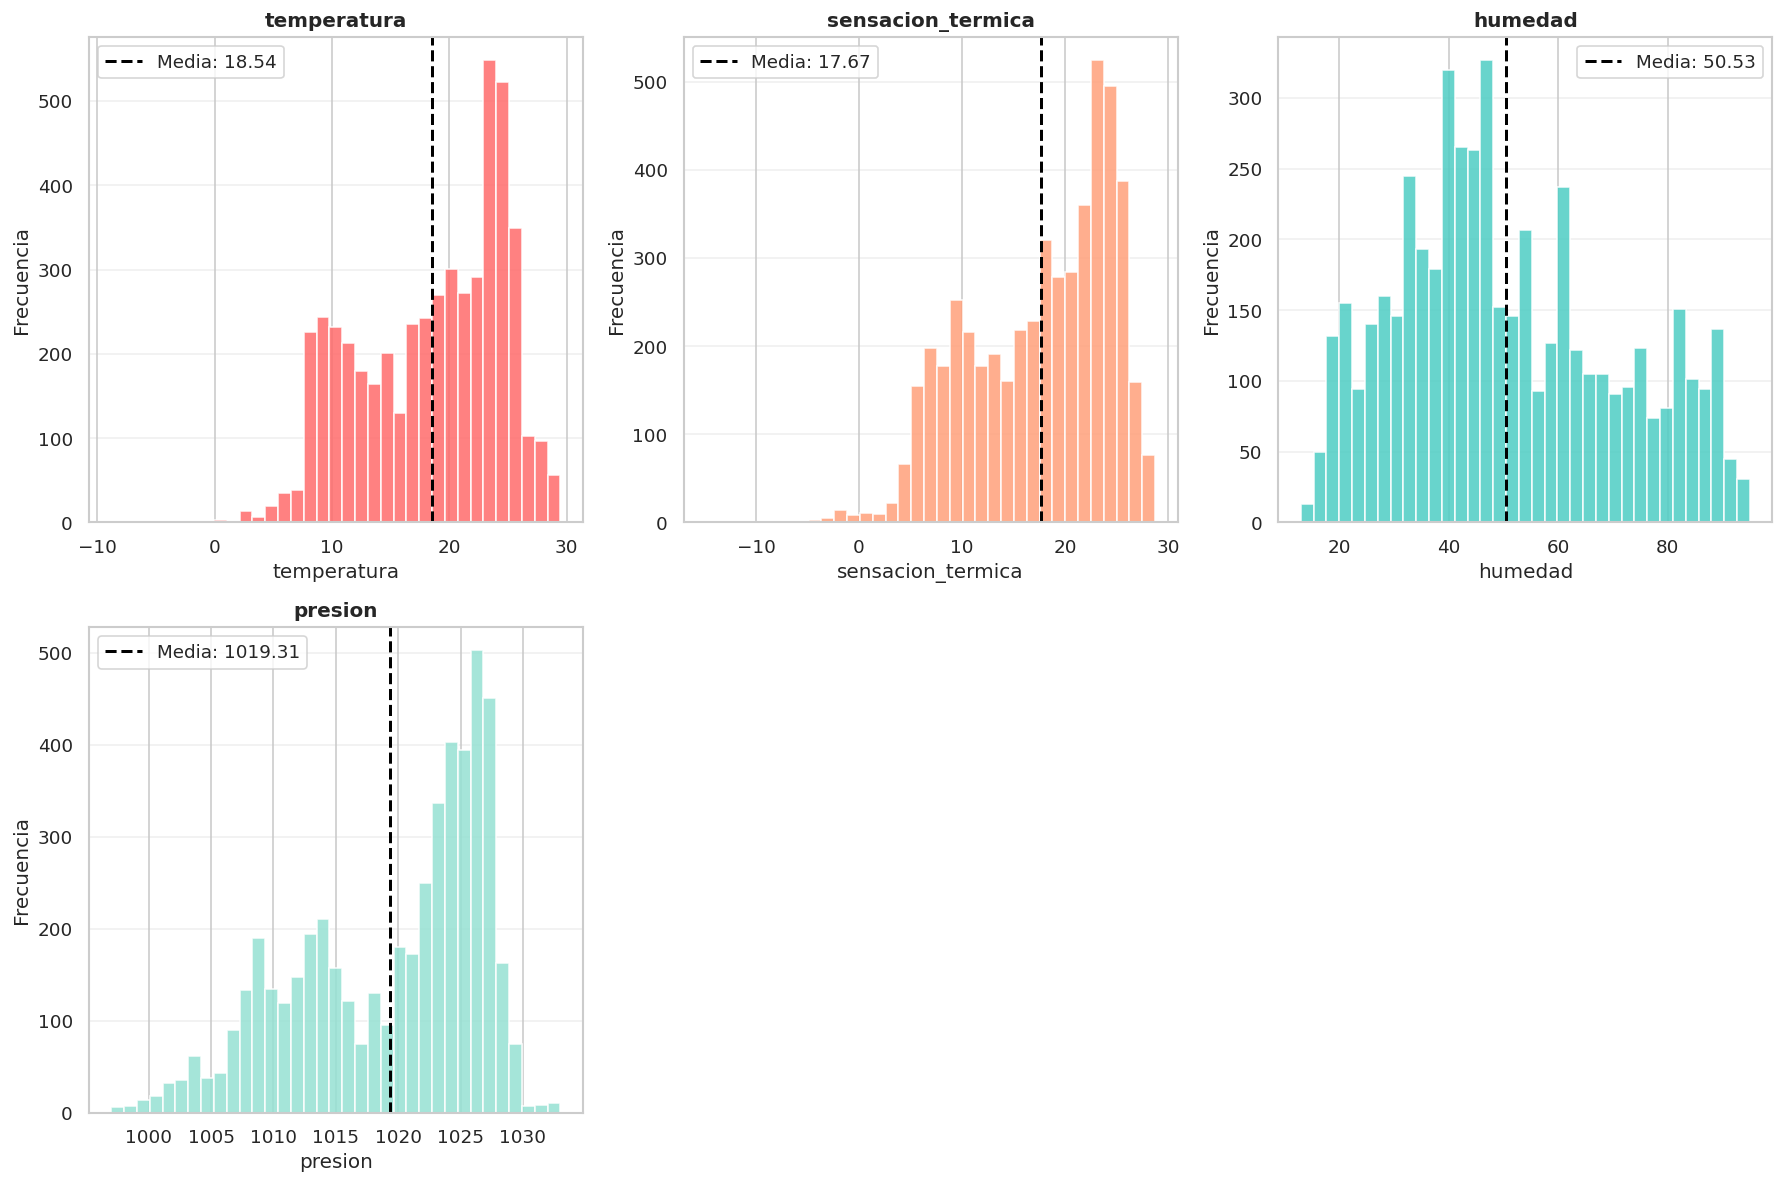

In [5]:
# ── CELDA 5: Histogramas de distribución ─────────────────────

import math
import matplotlib.pyplot as plt

# seleccionar variables numéricas (excluyendo IDs)
vars_num = [
    col for col in df.select_dtypes(include=['number']).columns
    if 'id' not in col.lower()
]

# paleta de colores 
colors = [
    '#ff6b6b', '#ffa07a', '#4ecdc4', '#95e1d3',
    '#6c5ce7', '#fdcb6e', '#00b894', '#0984e3'
]

# calcular filas y columnas dinámicamente
cols = 3
rows = math.ceil(len(vars_num) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(vars_num):
    color = colors[i % len(colors)]  # ciclo de colores
    
    media = df[col].mean()

    axes[i].hist(
        df[col],
        bins=35,
        color=color,
        edgecolor='white',
        alpha=0.85
    )

    # línea de la media
    axes[i].axvline(
        media,
        color='black',
        linestyle='--',
        linewidth=1.8,
        label=f'Media: {media:.2f}'
    )

    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)

# eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../data/graficas/histogramas_distribucion.png',
            dpi=150,
            bbox_inches='tight')
plt.show()



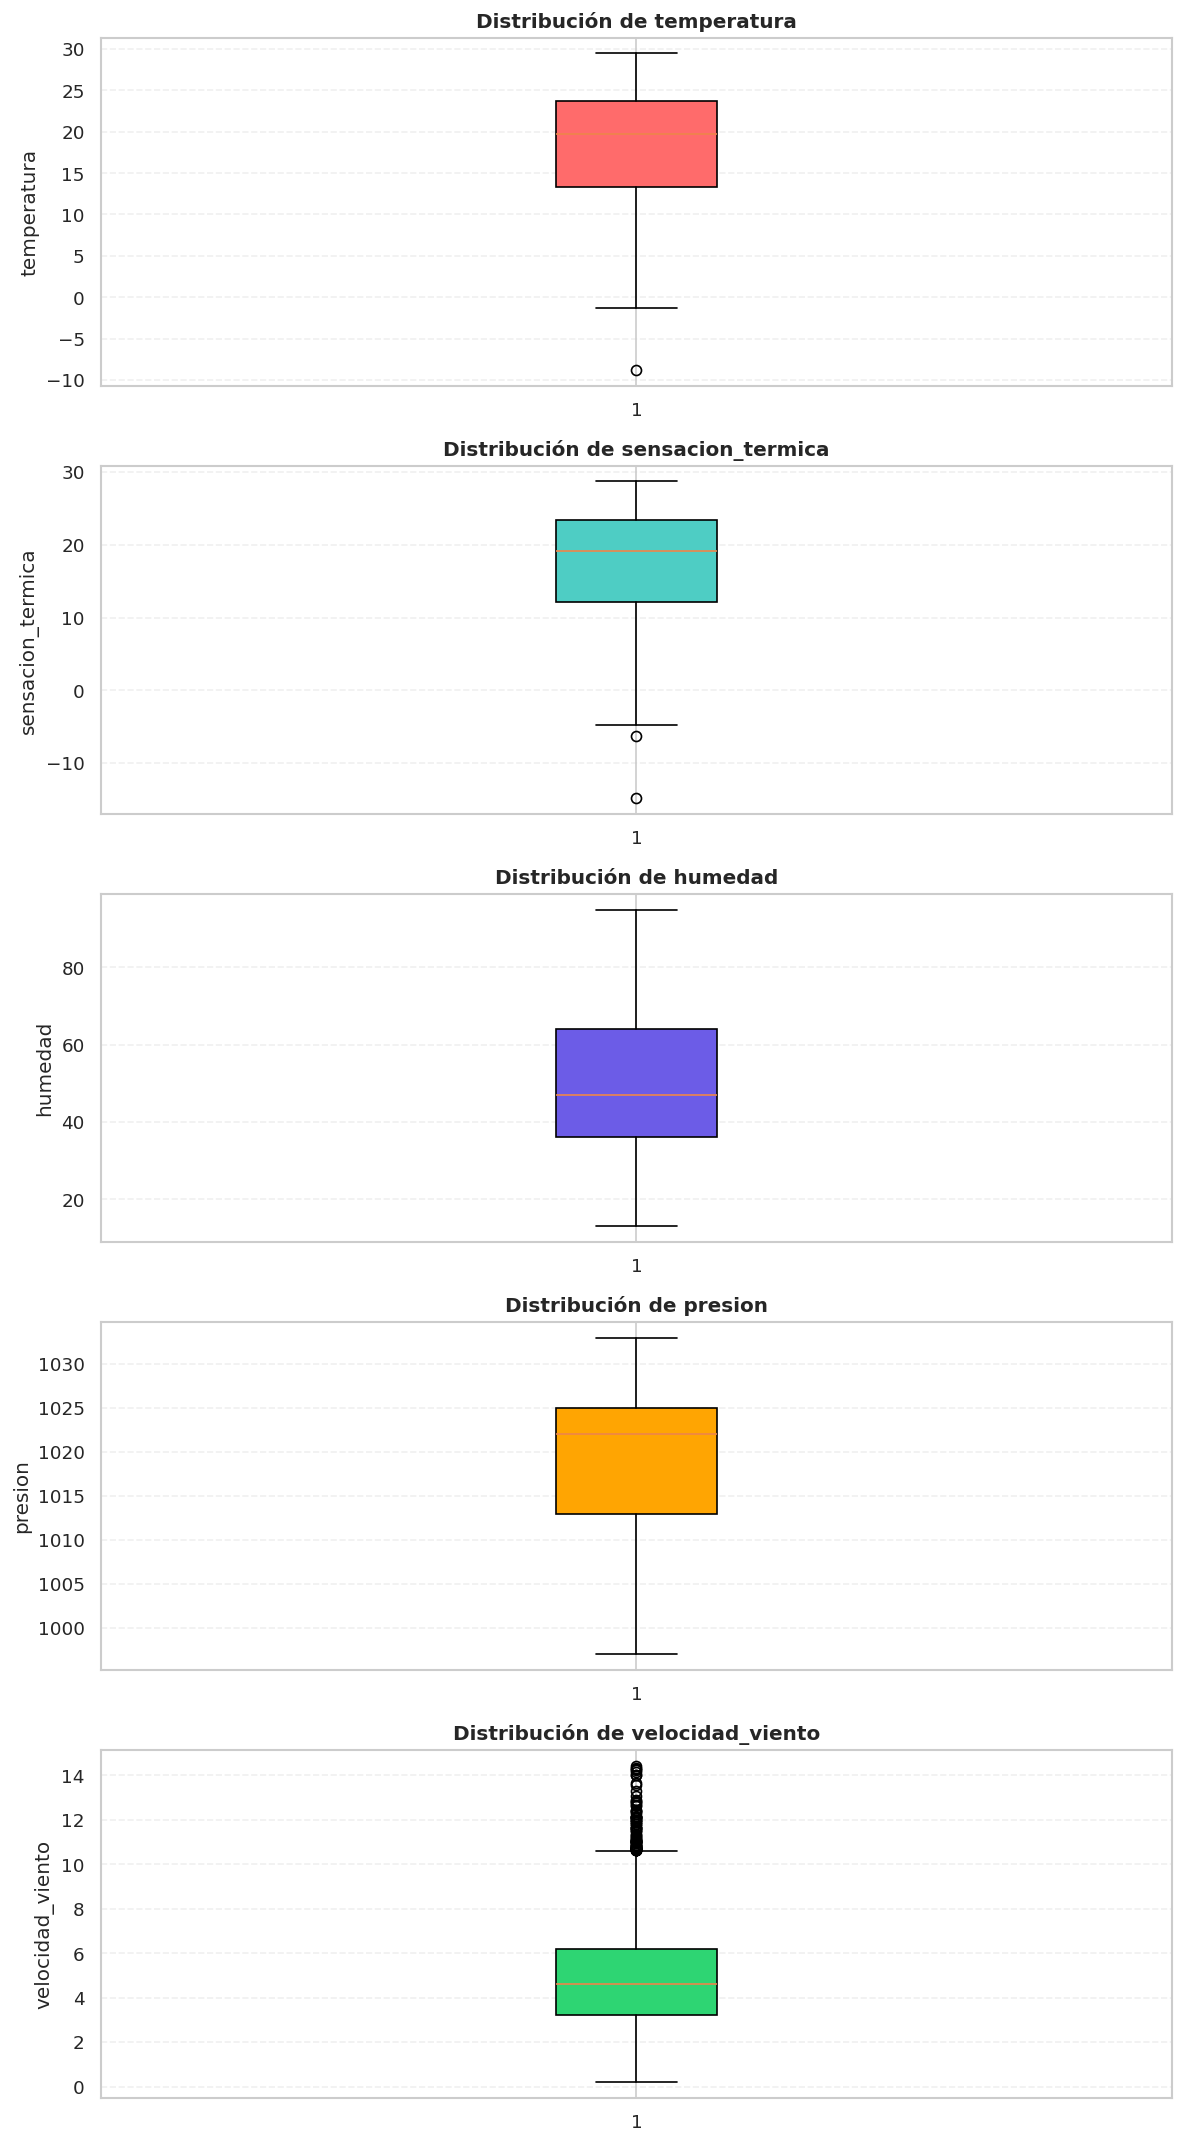

In [6]:
# ── CELDA 6: Boxplots individuales de variables ─────────────────────────────

# ── 1. Lista de variables ─────────────────────
variables = [
    "temperatura",
    "sensacion_termica",
    "humedad",
    "presion",
    "velocidad_viento"
]

# ── 2. Crear figura con subplots ─────────────────────
fig, axes = plt.subplots(len(variables), 1, figsize=(10, 18))

# ── 3. Colores ─────────────────────
colores = ['#ff6b6b', '#4ecdc4', '#6c5ce7', '#ffa502', '#2ed573']

# ── 4. Generar boxplot por cada variable ─────────────────────
for i, var in enumerate(variables):
    axes[i].boxplot(
        df[var],
        patch_artist=True,
        boxprops=dict(facecolor=colores[i])
    )

    axes[i].set_title(f'Distribución de {var}', fontweight='bold')
    axes[i].set_ylabel(var)
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

# ── 5. Ajuste final y guardado ─────────────────────
plt.tight_layout()
plt.savefig('../data/graficas/boxplots_variables.png', dpi=150, bbox_inches='tight')
plt.show()


📌 Variables usadas en correlación:
['temperatura', 'sensacion_termica', 'humedad', 'presion', 'velocidad_viento']


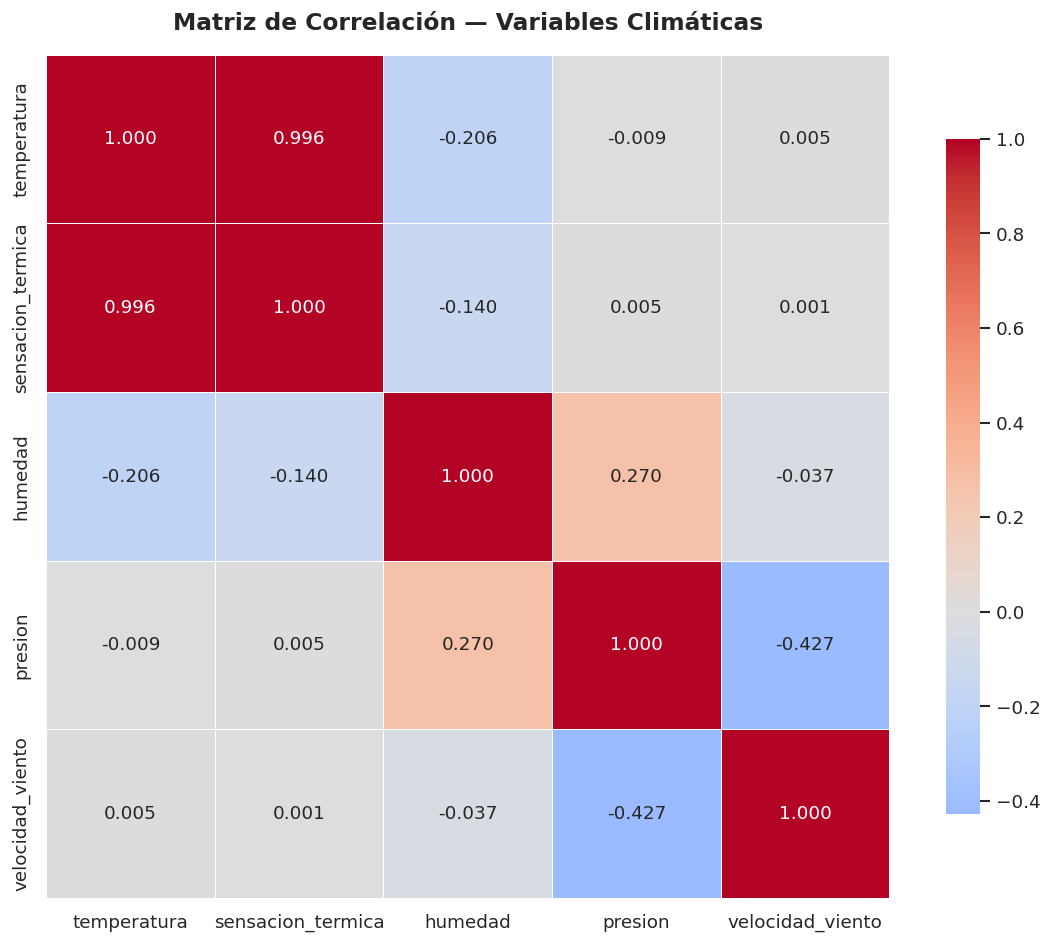


🔍 Top relaciones entre variables:
           Variable_1         Variable_2  Correlacion
0         temperatura  sensacion_termica     0.996365
4   sensacion_termica        temperatura     0.996365
15            presion   velocidad_viento    -0.427378
19   velocidad_viento            presion    -0.427378
14            presion            humedad     0.269703


In [29]:
# ── CELDA 7: Matriz de correlación ─────────────────────────────

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ── 1. Forzar tipos numéricos correctamente ─────────────
for col in ['temperatura', 'sensacion_termica', 'humedad', 'presion', 'velocidad_viento']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 2. Selección EXPLÍCITA de variables ─────────────
vars_num = [
    'temperatura',
    'sensacion_termica',
    'humedad',
    'presion',
    'velocidad_viento'
]

print("\n📌 Variables usadas en correlación:")
print(vars_num)

# ── 3. Matriz de correlación ─────────────────────────────
corr = df[vars_num].corr(method='spearman')

# ── 4. Heatmap ─────────────────────────────
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 11}
)

plt.title(
    "Matriz de Correlación — Variables Climáticas",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.savefig('../data/graficas/matriz_correlacion.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

# ── 5. Relaciones más fuertes ─────────────────────────────
corr_matrix = corr.copy()
np.fill_diagonal(corr_matrix.values, np.nan)

corr_pairs = (
    corr_matrix
    .unstack()
    .dropna()
    .reset_index()
)

corr_pairs.columns = ['Variable_1', 'Variable_2', 'Correlacion']

corr_pairs['abs_corr'] = corr_pairs['Correlacion'].abs()
corr_pairs = corr_pairs.sort_values(by='abs_corr', ascending=False)

print("\n🔍 Top relaciones entre variables:")
print(corr_pairs[['Variable_1', 'Variable_2', 'Correlacion']].head(5))

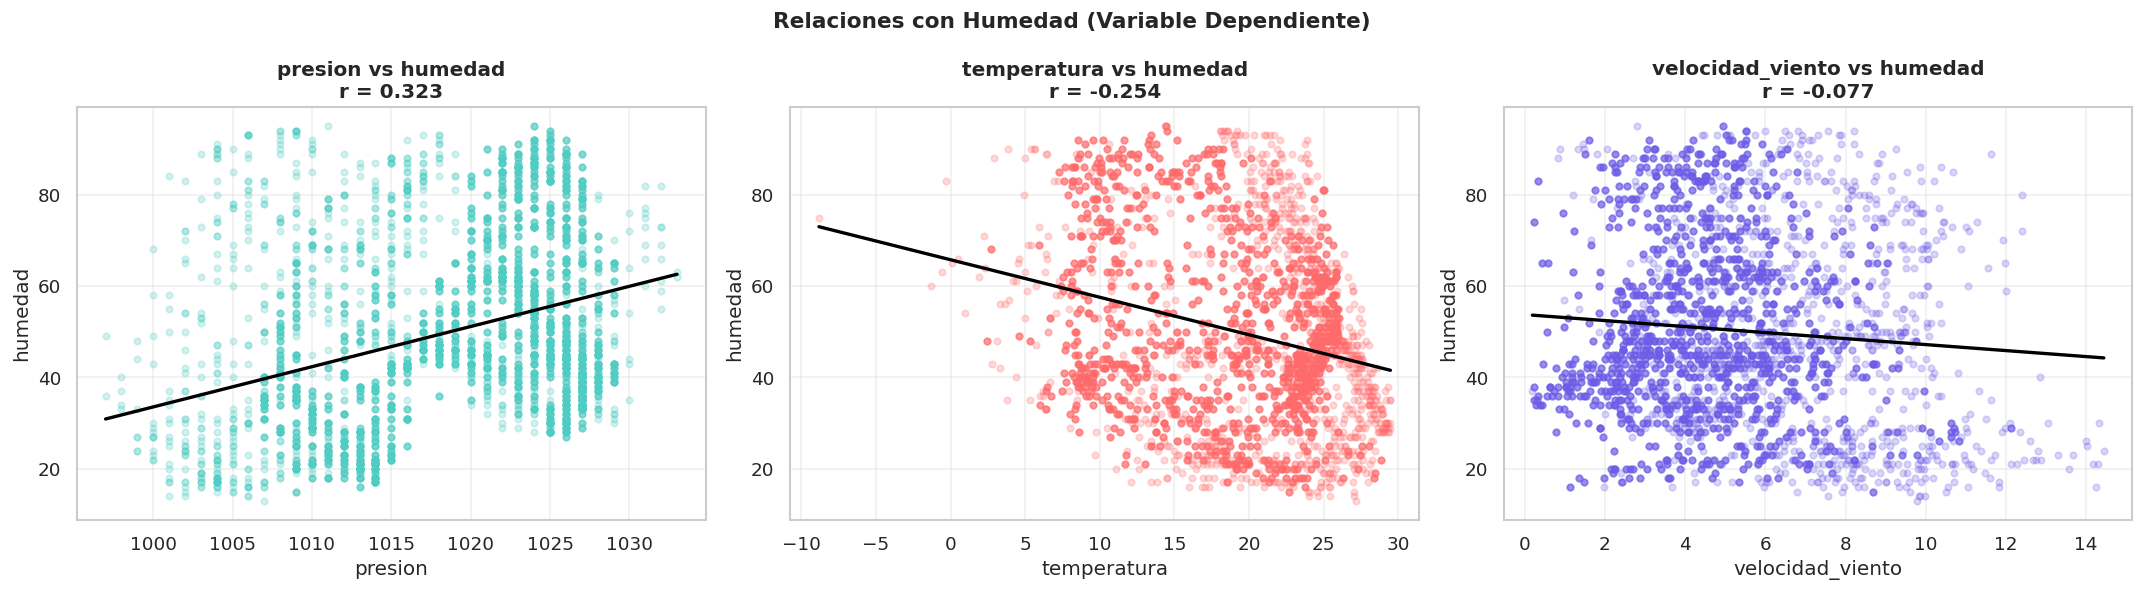

In [32]:
# ── CELDA 8: Scatter plots

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relaciones con Humedad (Variable Dependiente)',
             fontsize=13, fontweight='bold')

pares = [
    ('presion', 'humedad', '#4ecdc4'),            # relación positiva
    ('temperatura', 'humedad', '#ff6b6b'),        # relación negativa
    ('velocidad_viento', 'humedad', '#6c5ce7'),   # NUEVA relación
]

for ax, (x, y, color) in zip(axes, pares):

    # ── scatter ─────────────────────
    ax.scatter(
        df[x],
        df[y],
        alpha=0.25,
        s=15,
        color=color
    )

    # ── línea de tendencia ─────────────────────
    z = np.polyfit(df[x], df[y], 1)
    p = np.poly1d(z)
    xp = np.linspace(df[x].min(), df[x].max(), 200)
    ax.plot(xp, p(xp), color='black', linewidth=2)

    # ── correlación ─────────────────────
    r = df[[x, y]].corr().iloc[0, 1]

    ax.set_title(f'{x} vs {y}\nr = {r:.3f}', fontweight='bold')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/relaciones_humedad.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

In [9]:
# ── CELDA 9: Split Train / Test ───────────────────────────────

from sklearn.model_selection import train_test_split

# Variable independiente (X) y dependiente (Y)
X = df[['presion']].values
y = df['humedad'].values

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test : {X_test.shape[0]} muestras")

Train: 4000 muestras
Test : 1000 muestras


In [10]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────

from sklearn.linear_model import LinearRegression

# Crear modelo
modelo = LinearRegression()

# Entrenar
modelo.fit(X_train, y_train)

# Predecir
y_pred = modelo.predict(X_test)

# Resultados
print(f"Intercepto β0: {modelo.intercept_:.4f}")
print(f"Coeficiente β1: {modelo.coef_[0]:.4f}")

print(
    f"\nEcuación:\n"
    f"humedad = {modelo.intercept_:.3f} "
    f"+ {modelo.coef_[0]:.3f} * presion"
)

Intercepto β0: -833.0296
Coeficiente β1: 0.8670

Ecuación:
humedad = -833.030 + 0.867 * presion


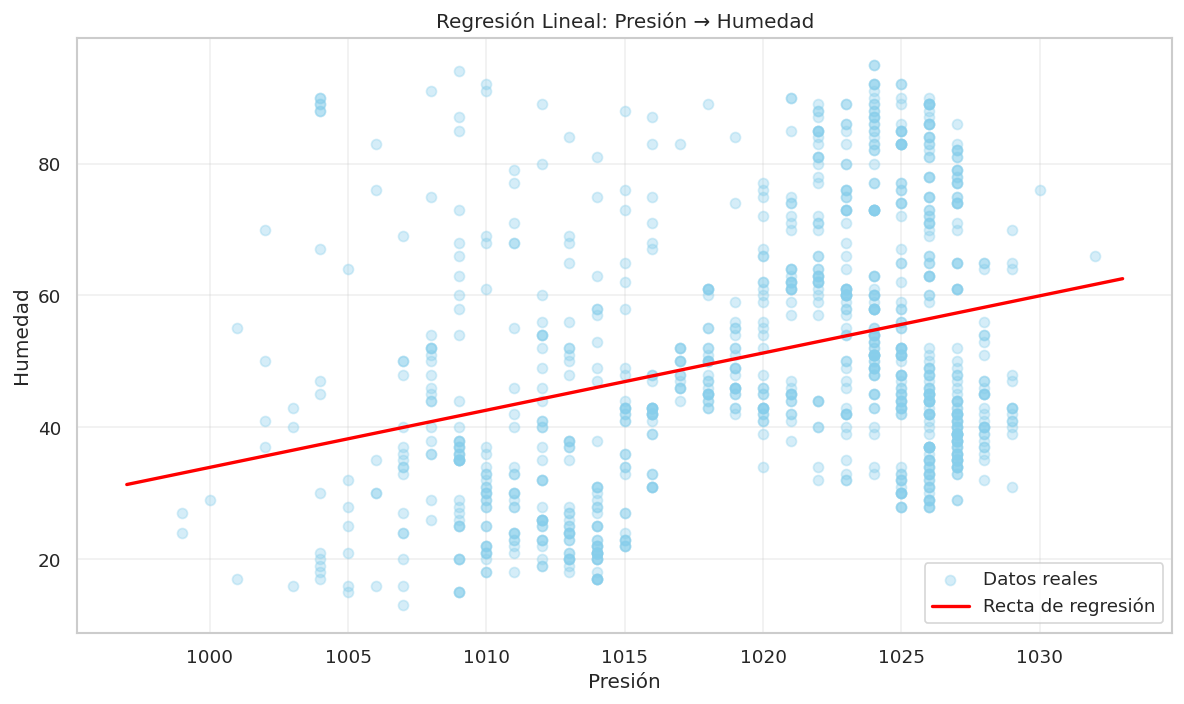

In [11]:
# ── CELDA 11: Recta de regresión (Presión → Humedad) ─────────

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Datos reales
plt.scatter(
    X_test,
    y_test,
    alpha=0.35,
    color="skyblue",
    label="Datos reales"
)

# Línea de regresión
x_line = np.linspace(X.min(), X.max(), 300).reshape(-1,1)

plt.plot(
    x_line,
    modelo.predict(x_line),
    color="red",
    linewidth=2,
    label="Recta de regresión"
)

plt.xlabel("Presión")
plt.ylabel("Humedad")
plt.title("Regresión Lineal: Presión → Humedad")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/regresion_presion_humedad.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

In [12]:
# ── CELDA 12: Métricas del modelo ────────────────────────────

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print("=" * 48)
print("      MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)

print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med) : {mse:.4f}")
print(f"  RMSE (raíz del MSE)         : {rmse:.4f}")
print(f"  MAE  (error absoluto medio) : {mae:.4f}")

print("=" * 48)

      MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.1106  (11.06%)
  MSE  (error cuadrático med) : 343.8788
  RMSE (raíz del MSE)         : 18.5440
  MAE  (error absoluto medio) : 15.5177


In [33]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────


# variable independiente
X_ols = df[['presion']]

# agregar constante (β0)
X_ols = sm.add_constant(X_ols)

# variable dependiente
y_ols = df['humedad']

# ajustar modelo OLS
modelo_ols = sm.OLS(y_ols, X_ols).fit()

# mostrar resumen estadístico
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                humedad   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     580.2
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          2.22e-121
Time:                        17:32:47   Log-Likelihood:                -21749.
No. Observations:                5000   AIC:                         4.350e+04
Df Residuals:                    4998   BIC:                         4.351e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -846.5031     37.242    -22.730      0.0

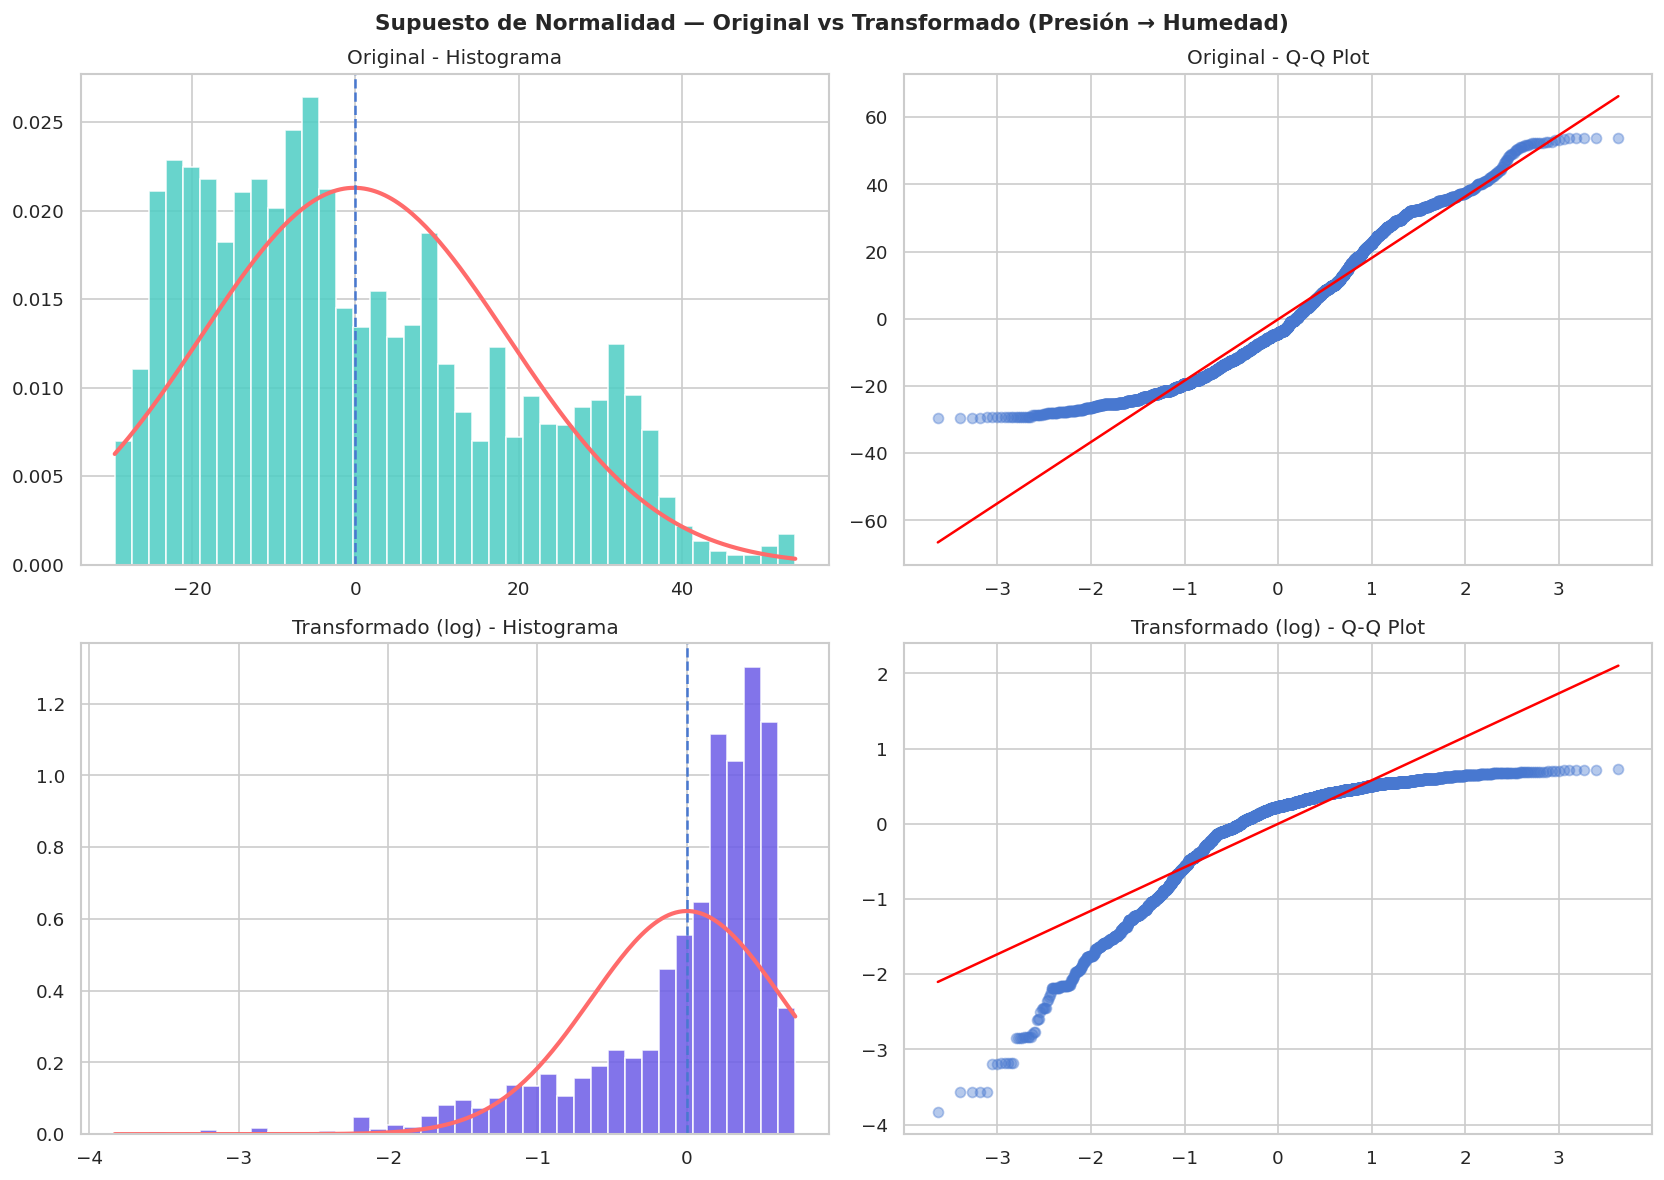


🔬 Test de Shapiro-Wilk (Original):
   Estadístico W : 0.9479
   p-value       : 0.000000
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot

🔬 Test de Shapiro-Wilk (Transformado):
   Estadístico W : 0.8122
   p-value       : 0.000000
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot


In [14]:
# ── CELDA 14: Normalidad de residuos (Original vs Transformado) ─────

from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ── ORIGINAL ─────────────────────────
y_pred_all = modelo.predict(df[['presion']].values)
residuos = df['humedad'].values - y_pred_all

# ── TRANSFORMACIÓN (invertir + log) ───
y_inv = np.max(df['humedad']) - df['humedad'] + 1
y_log = np.log(y_inv)

# nuevo modelo con variable transformada
modelo_log = LinearRegression()
modelo_log.fit(df[['presion']], y_log)

y_pred_log = modelo_log.predict(df[['presion']])
residuos_log = y_log - y_pred_log

# ── GRÁFICAS ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Supuesto de Normalidad — Original vs Transformado (Presión → Humedad)',
    fontsize=13,
    fontweight='bold'
)

# ===== ORIGINAL =====
# Histograma
axes[0,0].hist(
    residuos,
    bins=40,
    color='#4ecdc4',
    edgecolor='white',
    density=True,
    alpha=0.85
)

xr = np.linspace(residuos.min(), residuos.max(), 200)

axes[0,0].plot(
    xr,
    stats.norm.pdf(xr, residuos.mean(), residuos.std()),
    color='#ff6b6b',
    linewidth=2.5
)

axes[0,0].axvline(0, linestyle='--')
axes[0,0].set_title('Original - Histograma')

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')

axes[0,1].scatter(osm, osr, alpha=0.4)
axes[0,1].plot(osm, slope * np.array(osm) + intercept, color='red')
axes[0,1].set_title('Original - Q-Q Plot')

# ===== TRANSFORMADO =====
# Histograma
axes[1,0].hist(
    residuos_log,
    bins=40,
    color='#6c5ce7',
    edgecolor='white',
    density=True,
    alpha=0.85
)

xr2 = np.linspace(residuos_log.min(), residuos_log.max(), 200)

axes[1,0].plot(
    xr2,
    stats.norm.pdf(xr2, residuos_log.mean(), residuos_log.std()),
    color='#ff6b6b',
    linewidth=2.5
)

axes[1,0].axvline(0, linestyle='--')
axes[1,0].set_title('Transformado (log) - Histograma')

# Q-Q Plot
(osm2, osr2), (slope2, intercept2, r2) = stats.probplot(residuos_log, dist='norm')

axes[1,1].scatter(osm2, osr2, alpha=0.4)
axes[1,1].plot(osm2, slope2 * np.array(osm2) + intercept2, color='red')
axes[1,1].set_title('Transformado (log) - Q-Q Plot')

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_residuos.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

# ── TEST SHAPIRO-WILK ─────────────────────────

def shapiro_test(data, nombre):
    muestra = (
        data if len(data) <= 5000
        else np.random.default_rng(42).choice(data, 5000, replace=False)
    )

    stat, p = stats.shapiro(muestra)

    print(f"\n🔬 Test de Shapiro-Wilk ({nombre}):")
    print(f"   Estadístico W : {stat:.4f}")
    print(f"   p-value       : {p:.6f}")

    if p > 0.05:
        print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
    else:
        print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
        print("   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot")

# Ejecutar test
shapiro_test(residuos, "Original")
shapiro_test(residuos_log, "Transformado")

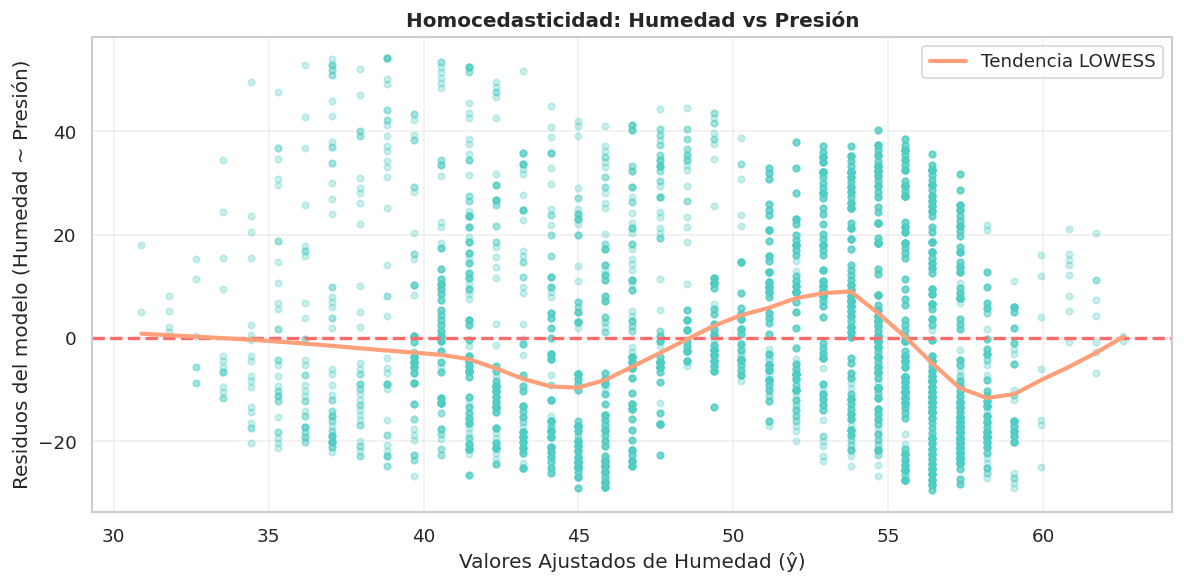


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 21.0020
   p-value        : 0.000005
   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)


In [37]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────



# residuos y valores ajustados del modelo OLS
residuos_ols  = modelo_ols.resid
ajustados_ols = modelo_ols.fittedvalues

plt.figure(figsize=(10, 5))

plt.scatter(
    ajustados_ols,
    residuos_ols,
    alpha=0.30,
    s=15,
    color='#4ecdc4'
)

plt.axhline(
    0,
    color='#ff6b6b',
    linestyle='--',
    linewidth=2
)

# Línea de tendencia LOWESS
lowess = sm.nonparametric.lowess(
    residuos_ols,
    ajustados_ols,
    frac=0.3
)

plt.plot(
    lowess[:, 0],
    lowess[:, 1],
    color='#ffa07a',
    linewidth=2.5,
    label='Tendencia LOWESS'
)

plt.xlabel('Valores Ajustados de Humedad (ŷ)', fontsize=12)
plt.ylabel('Residuos del modelo (Humedad ~ Presión)', fontsize=12)

plt.title(
    'Homocedasticidad: Humedad vs Presión',
    fontsize=12,
    fontweight='bold'
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/homoc_simple.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ── Test de Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols.model.exog
)

print("\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")



In [38]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Variables independientes (X)
FEATURES = ['presion', 'temperatura', 'velocidad_viento']

# Variable dependiente (Y)
TARGET = 'humedad'

# Eliminar nulos por seguridad (consistencia ETL)
df_multi = df.dropna(subset=FEATURES + [TARGET]).copy()

X_multi = df_multi[FEATURES].values
y_multi = df_multi[TARGET].values

# Split reproducible
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    random_state=42
)

# Entrenamiento del modelo múltiple
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

# Predicción
y_pred_multi = modelo_multi.predict(X_test_m)

# Resultados
print("📊 MODELO DE REGRESIÓN MÚLTIPLE")

print(f"Intercepto β₀: {modelo_multi.intercept_:.4f}")

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>18}: {coef:.4f}")

# ── 🔥 ECUACIÓN AUTOMÁTICA ─────────────────
ecuacion = f"humedad = {modelo_multi.intercept_:.3f}"

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    signo = "+" if coef >= 0 else "-"
    ecuacion += f" {signo} {abs(coef):.3f} * {feat}"

print("\n📐 Ecuación del modelo:")
print(ecuacion)

📊 MODELO DE REGRESIÓN MÚLTIPLE
Intercepto β₀: -932.2400
Coeficiente            presion: 0.9755
Coeficiente        temperatura: -0.8153
Coeficiente   velocidad_viento: 0.7545

📐 Ecuación del modelo:
humedad = -932.240 + 0.975 * presion - 0.815 * temperatura + 0.754 * velocidad_viento


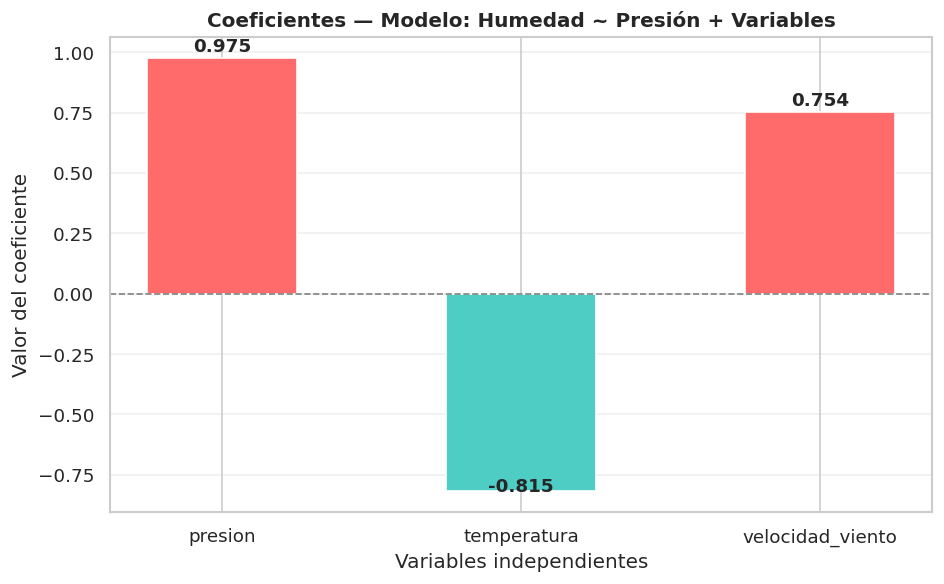

In [17]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────
# Modelo: Predecir HUMEDAD usando PRESIÓN + variables meteorológicas

import matplotlib.pyplot as plt

colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    FEATURES,
    modelo_multi.coef_,
    color=colores,
    edgecolor='white',
    width=0.5
)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title(
    'Coeficientes — Modelo: Humedad ~ Presión + Variables',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel('Valor del coeficiente')
ax.set_xlabel('Variables independientes')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.01 if coef >= 0 else -0.02
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f'{coef:.3f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/coeficientes_multi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [18]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────
# Modelo: Predecir HUMEDAD usando PRESIÓN, temperatura y viento

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 50)
print("  📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("  🎯 Objetivo: Humedad ~ Presión + Variables")
print("=" * 50)
print(f"  R²   (coef. determinación) : {r2_m:.4f}  ({r2_m * 100:.2f}%)")
print(f"  MSE  (error cuadrático)    : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)        : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio): {mae_m:.4f}")
print("=" * 50)

  📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  🎯 Objetivo: Humedad ~ Presión + Variables
  R²   (coef. determinación) : 0.2037  (20.37%)
  MSE  (error cuadrático)    : 307.8933
  RMSE (raíz del MSE)        : 17.5469
  MAE  (error absoluto medio): 14.5434


In [19]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────
# Modelo: Humedad ~ Presión + Temperatura + Velocidad del viento

import statsmodels.api as sm

# Variables independientes (X)
X_ols_m = sm.add_constant(df_multi[FEATURES])

# Variable dependiente (Y)
y_ols_m = df_multi['humedad']

# Ajuste del modelo OLS
modelo_ols_multi = sm.OLS(
    y_ols_m,
    X_ols_m
).fit()

# Resultados
print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                humedad   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     358.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          5.33e-211
Time:                        14:51:02   Log-Likelihood:                -21536.
No. Observations:                5000   AIC:                         4.308e+04
Df Residuals:                    4996   BIC:                         4.311e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -955.3811     39.996  

In [20]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────
# Modelo: Humedad ~ Presión + Temperatura + Velocidad del viento

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Usar dataset limpio (el mismo del modelo)
X_vif = df_multi[FEATURES].copy()

vif_data = pd.DataFrame()
vif_data["Variable"] = FEATURES

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data["VIF"] = vif_data["VIF"].round(3)

vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
    if v < 5 else (
        "⚠️ Moderada (5 ≤ VIF < 10)"
        if v < 10 else
        "❌ Severa (VIF ≥ 10)"
    )
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("🎯 Modelo: Humedad ~ Presión + Variables")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
🎯 Modelo: Humedad ~ Presión + Variables
        Variable    VIF                   Criterio
         presion 14.059        ❌ Severa (VIF ≥ 10)
     temperatura 10.198        ❌ Severa (VIF ≥ 10)
velocidad_viento  5.340 ⚠️ Moderada (5 ≤ VIF < 10)


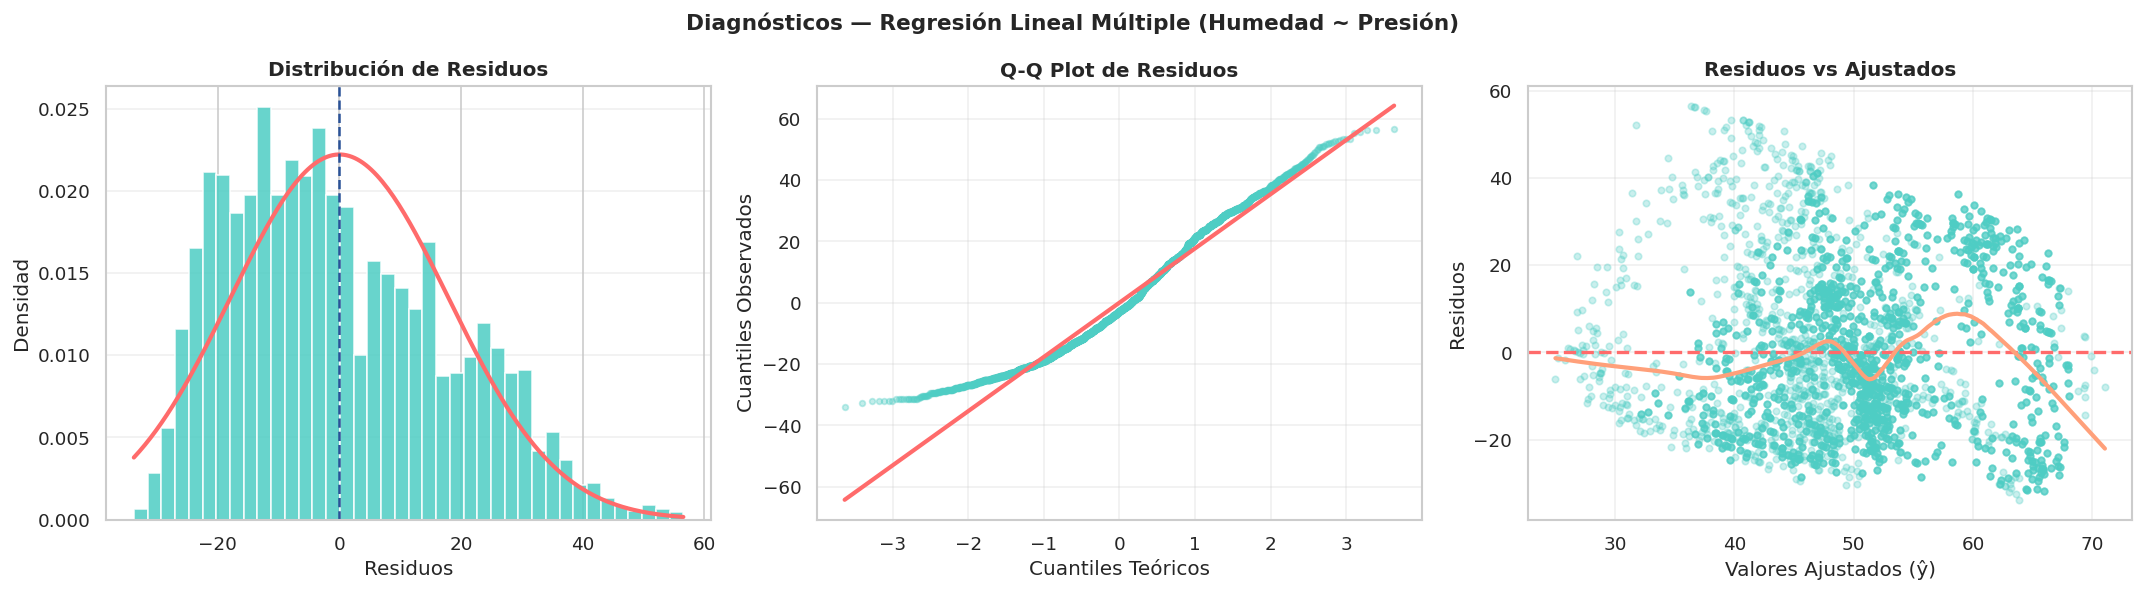


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.000000 → ⚠️ Se rechaza normalidad

🔬 Test Breusch-Pagan (Heterocedasticidad):
   p-value: 0.000000 → ⚠️ Heterocedasticidad detectada


In [21]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────
# Modelo: Humedad ~ Presión + Temperatura + Velocidad del viento

import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Diagnósticos — Regresión Lineal Múltiple (Humedad ~ Presión)',
    fontsize=13,
    fontweight='bold'
)

# ── Histograma de residuos
axes[0].hist(
    residuos_m,
    bins=40,
    color='#4ecdc4',
    edgecolor='white',
    density=True,
    alpha=0.85
)

xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)

axes[0].plot(
    xr,
    stats.norm.pdf(xr, np.mean(residuos_m), np.std(residuos_m)),
    color='#ff6b6b',
    linewidth=2.5
)

axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')

axes[1].scatter(
    osm,
    osr,
    alpha=0.35,
    s=12,
    color='#4ecdc4'
)

axes[1].plot(
    osm,
    s * np.array(osm) + i,
    color='#ff6b6b',
    linewidth=2.5
)

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── Residuos vs Ajustados
axes[2].scatter(
    ajustados_m,
    residuos_m,
    alpha=0.30,
    s=15,
    color='#4ecdc4'
)

axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

lowess_m = sm.nonparametric.lowess(
    residuos_m,
    ajustados_m,
    frac=0.3
)

axes[2].plot(
    lowess_m[:, 0],
    lowess_m[:, 1],
    color='#ffa07a',
    linewidth=2.5
)

axes[2].set_title('Residuos vs Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/diagnosticos_multi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ── Tests estadísticos

# Shapiro-Wilk (con límite de muestra por estabilidad)
muestra_m = (
    residuos_m
    if len(residuos_m) <= 5000
    else np.random.default_rng(42).choice(
        residuos_m,
        5000,
        replace=False
    )
)

stat_sw_m, p_sw_m = stats.shapiro(muestra_m)

lm_m, lm_p_m, _, _ = het_breuschpagan(
    residuos_m,
    modelo_ols_multi.model.exog
)

print("\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️ Se rechaza normalidad'}")

print("\n🔬 Test Breusch-Pagan (Heterocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️ Heterocedasticidad detectada'}")


In [22]:
# ── CELDA 22: Comparación final de modelos ───────────────────
# Modelos: Humedad ~ Presión vs Modelo múltiple

import pandas as pd

comparacion = pd.DataFrame({
    'Modelo': ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': [
        'presion',
        'presion + temperatura + velocidad_viento'
    ],
    'R²': [
        round(r2, 4),
        round(r2_m, 4)
    ],
    'R² Aj.': [
        round(modelo_ols.rsquared_adj, 4),
        round(modelo_ols_multi.rsquared_adj, 4)
    ],
    'RMSE': [
        round(rmse, 4),
        round(rmse_m, 4)
    ],
    'MAE': [
        round(mae, 4),
        round(mae_m, 4)
    ],
    'AIC': [
        round(modelo_ols.aic, 2),
        round(modelo_ols_multi.aic, 2)
    ],
    'BIC': [
        round(modelo_ols.bic, 2),
        round(modelo_ols_multi.bic, 2)
    ],
})

print("=" * 85)
print("              📊 COMPARACIÓN FINAL DE MODELOS")
print("         🎯 Objetivo: Predecir HUMEDAD")
print("=" * 85)
print(comparacion.to_string(index=False))
print("=" * 85)

print("\n📌 Interpretación:")
print("- R² y R² ajustado → qué modelo explica mejor la humedad")
print("- RMSE y MAE → menor error = mejor predicción")
print("- AIC/BIC → menor valor = mejor balance entre ajuste y complejidad")

              📊 COMPARACIÓN FINAL DE MODELOS
         🎯 Objetivo: Predecir HUMEDAD
            Modelo                                Variables     R²  R² Aj.    RMSE     MAE      AIC      BIC
  Regresión Simple                                  presion 0.9012  0.1038 18.5440 15.5177 43501.33 43514.37
Regresión Múltiple presion + temperatura + velocidad_viento 0.2037  0.1767 17.5469 14.5434 43079.01 43105.08

📌 Interpretación:
- R² y R² ajustado → qué modelo explica mejor la humedad
- RMSE y MAE → menor error = mejor predicción
- AIC/BIC → menor valor = mejor balance entre ajuste y complejidad


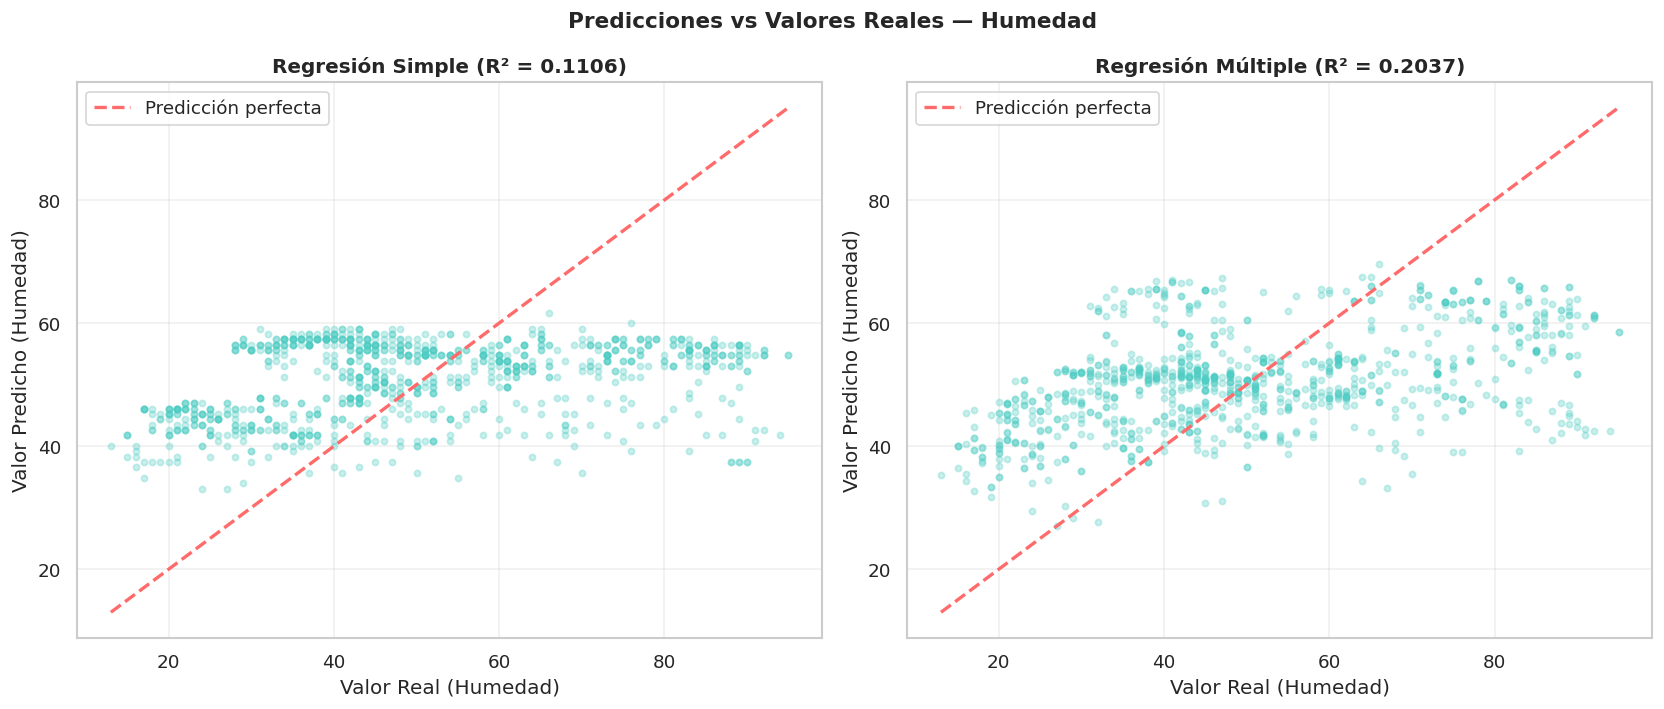

In [23]:
# ── CELDA 23: Predicciones vs Valores Reales — ambos modelos ─────────
# Modelo: Humedad ~ Presión + Variables

from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Predicciones vs Valores Reales — Humedad',
    fontsize=13,
    fontweight='bold'
)

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred,       'Regresión Simple'),
    (y_test_m, y_pred_multi, 'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())

    ax.scatter(
        y_real,
        y_pred,
        alpha=0.30,
        s=14,
        color='#4ecdc4'
    )

    ax.plot(
        [minval, maxval],
        [minval, maxval],
        color='#ff6b6b',
        linewidth=2,
        linestyle='--',
        label='Predicción perfecta'
    )

    r2_val = r2_score(y_real, y_pred)

    ax.set_title(
        f'{titulo} (R² = {r2_val:.4f})',
        fontweight='bold'
    )

    ax.set_xlabel('Valor Real (Humedad)')
    ax.set_ylabel('Valor Predicho (Humedad)')

    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/predicciones_vs_reales.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()